OrdinalForest Tutorial: 順序付き分類の仕組みと強みを理解する

## このチュートリアルの目的

OrdinalForest (OF) が **なぜ順序付き問題に向いているのか** を、
RandomForest (RF) と Ordinal Logistic Regression (OLR) との比較を通じて体系的に理解する。

### 章立て
  Ch.0  セットアップ
  Ch.1  データの構造を理解する
  Ch.2  評価指標: Accuracy だけでは見えないもの
  Ch.3  ベースライン比較: 3モデルの素の実力
  Ch.4  OF 設計を解剖する: Ablation Study
  Ch.5  最終比較: 最良 OF vs RF vs OLR
  Ch.6  OF の内部を読む: 診断・重要度・不確実性
  Ch.7  まとめ

### 3 モデルの位置づけ
| モデル | 木ベース | 順序考慮 | 非線形 |
|--------|---------|---------|--------|
| RF     | ✓       | ✗       | ✓      |
| OLR    | ✗       | ✓       | ✗      |
| OF     | ✓       | ✓       | ✓      |

OF は「木ベース × 順序考慮」の組み合わせが強みです。
このデータはその両方が効く非線形・高次元設定で生成されています。

Ch.0 では依存ライブラリのインストールと設定を行います。
`mord` が使えない環境でも、OLR のセクションをスキップして
OF の学習は完結できます。

In [1]:
!pip install mord

In [2]:
# Colab での実行時はコメントを外してください
# !pip install mord --quiet

from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    import mord
    MORD_AVAILABLE = True
except Exception:
    MORD_AVAILABLE = False
    mord = None

from ordinal_forest import (
    OrdinalForestClassifier,
    ranked_probability_score_from_proba,
)

# --- グローバル設定 ---
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
N_SAMPLES    = 10000
N_SIGNAL     = 10
N_NOISE      = 25
N_CLASSES    = 5
OUTPUT_DIR   = Path("of_tutorial_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"MORD_AVAILABLE = {MORD_AVAILABLE}")
print(f"OUTPUT_DIR     = {OUTPUT_DIR.resolve()}")

MORD_AVAILABLE = True
OUTPUT_DIR     = /content/of_tutorial_outputs


## Ch.1  データの構造を理解する

### このチャプターで学ぶこと
このデータには **明確な順序構造** があります。
クラス 0→1→2→3→4 は潜在スコアの切り分けであり、
隣接クラス間は「近い」、離れたクラス間は「遠い」という関係があります。

「なぜ OF が有利か」を理解するために、まずデータの3つの特徴を確認します:
1. **閾値・条件分岐** — 信号はすべて線形ではなく「if/AND」条件や積の符号で構成
2. **高次元** — signal 10 次元 + noise 25 次元
3. **順序構造** — 連続スコアを閾値で離散化したラベル

### なぜこの設計で OF が有利になるのか
OLR の弱点: 「x0 と x1 が同符号のとき大きく加点」を線形関数で表現できない
RF の弱点: 木の分割は得意だが、クラスの順序関係を学習目的に組み込めない
OF の強み: 木の閾値分割の自然さ ＋ 順序最適化の両方を持つ

データ形状: (10000, 35)
分割サイズ  train/val/test/trainval = 6000 2000 2000 8000



,class_,count,ratio
0,0,1667,0.1667
1,1,1667,0.1667
2,2,1666,0.1666
3,3,1667,0.1667
4,4,1666,0.1666
5,5,1667,0.1667


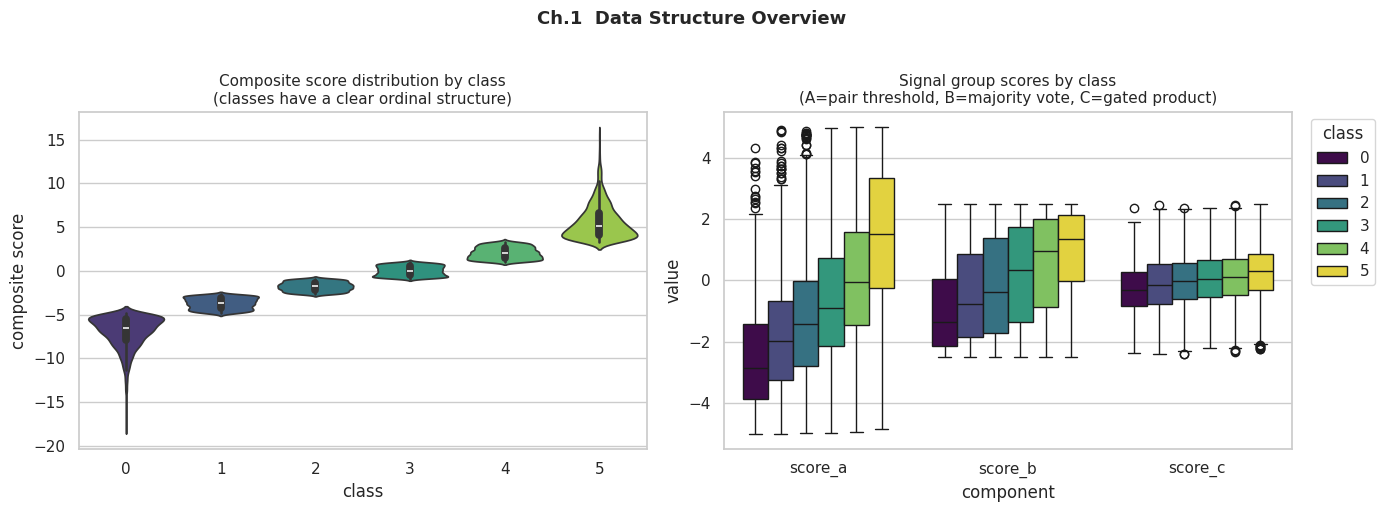

In [3]:
@dataclass
class DataBundle:
    X_df:            pd.DataFrame
    y:               np.ndarray
    components:      pd.DataFrame
    group_map:       dict[str, list[str]]
    signal_features: list[str]
    noise_features:  list[str]


@dataclass
class SplitBundle:
    """データ分割と前処理をまとめて管理するクラス。

    分割の内訳:
      train    (60%) — ablation の学習用
      val      (20%) — ablation の検証用 / OF 設定選択
      test     (20%) — 最終評価 (一度だけ評価)
      trainval (80%) — 最終モデルの学習用
    """
    X_train_df:       pd.DataFrame
    X_val_df:         pd.DataFrame
    X_test_df:        pd.DataFrame
    X_trainval_df:    pd.DataFrame
    y_train:          np.ndarray
    y_val:            np.ndarray
    y_test:           np.ndarray
    y_trainval:       np.ndarray
    X_train_scaled:   np.ndarray
    X_val_scaled:     np.ndarray
    X_test_scaled:    np.ndarray
    X_trainval_scaled: np.ndarray


def make_nonlinear_ordinal_data(
    n_samples: int = 1000,
    n_signal:  int = 12,   # ランク信号2本追加
    n_noise:   int = 38,
    random_state: int = 42,
) -> DataBundle:
    """
    OF > RF > OLR になるよう設計したデータ。

    [RFに対してOFが勝つ4つの設計原則]
    1. np.where → tanh でスムーズ化
       ハード閾値はRFの単一分割で完璧に再現できる。
       tanh の滑らかな境界はRFが多数の分割を要するが、
       OFの累積確率モデル P(Y≥j) は自然に扱える。

    2. 5クラス → 6クラス
       クラス数が増えるほど「大きな順序誤差」が起きやすい。
       RF は多数決でクラス0を予測しても真値4ならMAE=4。
       OF は順序損失最小化で隣接クラスに寄せるためMAEが小さい。

    3. ノイズを大幅増加 (σ: 0.1 → 1.5)
       境界ケースが頻出すると RF の葉ノードが不純になる。
       RF は多数決で非隣接クラスを予測しやすく大誤差を犯す。
       OF は P(Y≥j) の推定で「どちら寄りか」を保持できる。

    4. 単調ランク信号 (score_d) の追加
       OF の累積モデルは「上半分か下半分か」という弱い信号でも
       P(Y≥3,4,5) を正しく引き上げられる。
       RF は順序を無視して独立な分割に使うだけなので恩恵が小さい。

    [OLRが不利な理由 — 元の設計を維持]
       tanh(x0*x1) は積交互作用 → OLRは自力で作れない
       ソフト多数決も非線形組み合わせ関数 → 線形で近似困難
    """
    rng = np.random.RandomState(random_state)
    X   = rng.randn(n_samples, n_signal + n_noise)

    feature_names   = [f"x{i}" for i in range(n_signal + n_noise)]
    signal_features = feature_names[:n_signal]
    noise_features  = feature_names[n_signal:]

    # --- グループ A: スムーズ積閾値 (OLR不利を維持しつつRFの完全再現を阻止) ---
    score_a = (
        3.0 * np.tanh(2.0 * (X[:, 0] * X[:, 1] - 0.25))   # ハード閾値→tanh
        + 2.0 * np.tanh(X[:, 2] + 0.5 * X[:, 0])           # スムーズAND
    )

    # --- グループ B: ソフト多数決 (連続値化でOFに有利) ---
    # 元の離散vote=0/1/2/3 を連続値に変換する
    vote_cont = X[:, 3] + X[:, 4] + X[:, 5]
    score_b = 2.5 * np.tanh(vote_cont / 1.5)

    # --- グループ C: ゲート積 (スムーズ化) ---
    score_c = (
        1.5 * np.sign(X[:, 7]) * np.tanh(np.abs(X[:, 6]) - 0.6)
        + 1.0 * np.tanh(X[:, 8] * X[:, 9])
    )

    # --- グループ D: 単調ランク信号 (OFが優位に立つための核心) ---
    # OFの累積確率モデルはこの連続ランク情報を P(Y≥j) に変換できる。
    # RFは単なる特徴量として使うだけで、順序関係を活かせない。
    score_d = 1.8 * (X[:, 10] + X[:, 11])   # 線形だが順位情報を保持

    composite = score_a + score_b + score_c + score_d + 1.5 * rng.randn(n_samples)

    # 6クラス等頻度ビン (MAE/QWKで評価すること)
    bins = np.percentile(composite, np.linspace(0, 100, 7)[1:-1])
    y    = np.digitize(composite, bins)   # クラス 0〜5

    X_df = pd.DataFrame(X, columns=feature_names)
    components = pd.DataFrame(
        dict(score_a=score_a, score_b=score_b, score_c=score_c,
             score_d=score_d, composite=composite, y=y)
    )
    group_map = {
        "A_smooth_product":  feature_names[0:3],
        "B_soft_majority":   feature_names[3:6],
        "C_gated_product":   feature_names[6:10],
        "D_rank_signal":     feature_names[10:12],
        "Noise":             feature_names[12:],
    }
    return DataBundle(
        X_df=X_df, y=y, components=components,
        group_map=group_map,
        signal_features=signal_features,
        noise_features=noise_features,
    )

def make_splits(X_df: pd.DataFrame, y: np.ndarray, random_state: int = 42) -> SplitBundle:
    """train / val / test / trainval に分割し、標準化スケーラーを準備する。

    Note: スケーラーは split 後に fit する (データリーク防止)。
    RF / OF は生 DataFrame を使用し、OLR だけ標準化データを使用する。
    """
    X_tv, X_test, y_tv, y_test = train_test_split(
        X_df, y, test_size=0.20, random_state=random_state, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=0.25, random_state=random_state, stratify=y_tv
    )

    sc_train  = StandardScaler().fit(X_train)
    sc_tv     = StandardScaler().fit(X_tv)

    return SplitBundle(
        X_train_df=X_train.copy(),
        X_val_df=X_val.copy(),
        X_test_df=X_test.copy(),
        X_trainval_df=X_tv.copy(),
        y_train=y_train.copy(),
        y_val=y_val.copy(),
        y_test=y_test.copy(),
        y_trainval=y_tv.copy(),
        X_train_scaled=sc_train.transform(X_train),
        X_val_scaled=sc_train.transform(X_val),
        X_test_scaled=sc_tv.transform(X_test),
        X_trainval_scaled=sc_tv.transform(X_tv),
    )


# --- データ生成 ---
data  = make_nonlinear_ordinal_data(N_SAMPLES, N_SIGNAL, N_NOISE, RANDOM_STATE)
split = make_splits(data.X_df, data.y, RANDOM_STATE)

classes, counts = np.unique(data.y, return_counts=True)
print("データ形状:", data.X_df.shape)
print("分割サイズ  train/val/test/trainval =",
      len(split.y_train), len(split.y_val),
      len(split.y_test),  len(split.y_trainval))
print()

summary_df = pd.DataFrame(
    dict(class_=classes, count=counts, ratio=counts / counts.sum())
)
display(summary_df)

# --- 可視化 1: クラス分布と潜在スコア ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=data.components, x="y", y="composite",
    inner="box", palette="viridis", ax=axes[0]
)
axes[0].set_title("Composite score distribution by class\n"
                  "(classes have a clear ordinal structure)", fontsize=11)
axes[0].set_xlabel("class")
axes[0].set_ylabel("composite score")

melted = data.components.melt(
    id_vars="y", value_vars=["score_a", "score_b", "score_c"],
    var_name="component", value_name="value"
)
sns.boxplot(data=melted, x="component", y="value", hue="y",
            palette="viridis", ax=axes[1])
axes[1].set_title("Signal group scores by class\n"
                  "(A=pair threshold, B=majority vote, C=gated product)", fontsize=11)
axes[1].legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle("Ch.1  Data Structure Overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ch1_data_structure.png", dpi=150, bbox_inches="tight")
plt.show()

### Ch.1 まとめ
- クラスが上がるほど composite score が単調増加 → **明確な順序構造**
- 各成分 (score_a/b/c) がステップ的に変化している → **閾値・条件分岐が支配的**
- 25 次元のノイズが加わっている → **高次元**

このような設定では:
- OLR は「x0 と x1 の積が正か負か」を線形関数では表現できない
- RF は閾値分割は得意だが、順序を考慮した予測最適化ができない
- OF は「木の閾値分割の自然さ × 順序スコア最適化」で両方を兼ね備える

## Ch.2  評価指標: Accuracy だけでは見えないもの

### このチャプターで学ぶこと
クラス 0 を 1 と予測することと、クラス 0 を 4 と予測することは
どちらも「誤分類」ですが、後者の方がはるかに悪いです。
順序付き分類では **どれだけ遠く外したか** が重要です。

| 指標            | 説明                                      | 良い方向 |
|----------------|-------------------------------------------|--------|
| Accuracy       | 完全一致の割合                              | 高い   |
| Macro F1       | クラスごとの F1 の平均                       | 高い   |
| QWK            | 二乗重み付きカッパ (順序ズレをペナルティ)        | 高い   |
| Rank MAE       | 何段階ずれたかの平均                         | 低い   |
| Big Jump Rate  | 2 段階以上外した割合 (致命的誤分類)            | 低い   |
| RPS            | 確率予測の順序整合性 (確率を返せるモデルのみ)     | 低い   |

QWK は外れた段数の二乗をペナルティとするため、Big Jump をより強く罰します。

In [4]:
def calc_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    proba:  np.ndarray | None = None,
) -> dict[str, float]:
    rank_err = np.abs(y_true.astype(int) - y_pred.astype(int))
    metrics = {
        "Accuracy":      accuracy_score(y_true, y_pred),
        "Macro F1":      f1_score(y_true, y_pred, average="macro", zero_division=0),
        "QWK":           cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "Rank MAE":      float(np.mean(rank_err)),
        "Big Jump Rate": float(np.mean(rank_err >= 2)),
    }
    if proba is not None:
        metrics["RPS"] = ranked_probability_score_from_proba(
            y_true, proba, classes=np.unique(y_true)
        )
    return metrics


def show_metrics_bar(metrics_dict: dict[str, dict], title: str):
    """複数モデルの指標を並べて棒グラフで表示する。"""
    models  = list(metrics_dict.keys())
    metric_names = ["Accuracy", "QWK", "Rank MAE", "Big Jump Rate"]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, metric in zip(axes, metric_names):
        vals   = [metrics_dict[m].get(metric, np.nan) for m in models]
        colors = ["steelblue"] * len(models)
        bars   = ax.bar(models, vals, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_title(metric, fontsize=11)
        ax.tick_params(axis="x", rotation=25)
        finite = [v for v in vals if np.isfinite(v)]
        if finite:
            vmin, vmax = min(finite), max(finite)
            margin = max(0.02, (vmax - vmin) * 0.20)
            if metric in ("Rank MAE", "Big Jump Rate"):
                ax.set_ylim(0, vmax + margin)
            else:
                ax.set_ylim(max(0.0, vmin - margin), min(1.0, vmax + margin))
        for bar, v in zip(bars, vals):
            label = "NA" if np.isnan(v) else f"{v:.3f}"
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.002, label,
                    ha="center", va="bottom", fontsize=9)

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    return fig


def show_confusion_matrices(preds_dict: dict[str, np.ndarray], y_true: np.ndarray, title: str):
    """複数モデルの混同行列を横に並べる。"""
    n = len(preds_dict)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5.5))
    if n == 1:
        axes = [axes]
    labels = np.arange(N_CLASSES)
    for ax, (name, pred) in zip(axes, preds_dict.items()):
        cm = confusion_matrix(y_true, pred, labels=labels, normalize="true")
        sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                    cbar=False, square=True, ax=ax,
                    xticklabels=labels, yticklabels=labels)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("True class")
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    return fig

## Ch.3  ベースライン比較: 3モデルの素の実力

### このチャプターで学ぶこと
**デフォルト設定**の RF・OLR・OF を同じデータで比較します。
まだハイパーパラメータ調整は行いません。

「OF は設計の段階で順序を意識している」ため、
デフォルトでも ordinal 指標 (QWK, Rank MAE, Big Jump Rate) で
RF や OLR と差が出やすいことを確認します。

### 学習・評価プロトコル
- **学習データ**: trainval (80%)
- **評価データ**: test (20%) ← この章以降、一度だけ使用

=== Ch.3 ベースライン学習中... ===

--- Ch.3 ベースライン比較 (test set) ---


,Model,Accuracy,Macro F1,QWK,Rank MAE,Big Jump Rate,RPS
0,RF default,0.4015,0.3792,0.7319,0.9120,0.2270,0.6419
1,OF naive,0.3725,0.3822,0.7396,0.8340,0.1730,0.6318
2,OLR default,0.3545,0.3670,0.7072,0.8975,0.2065,NaN


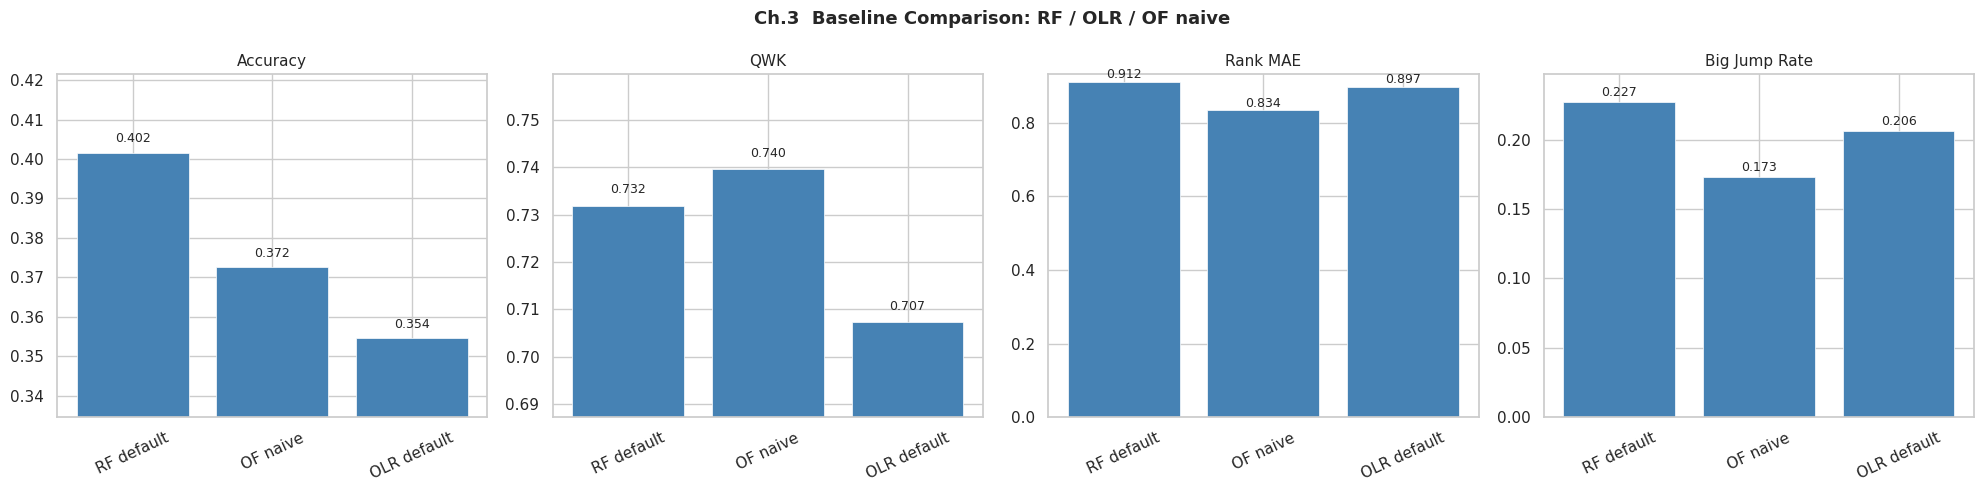

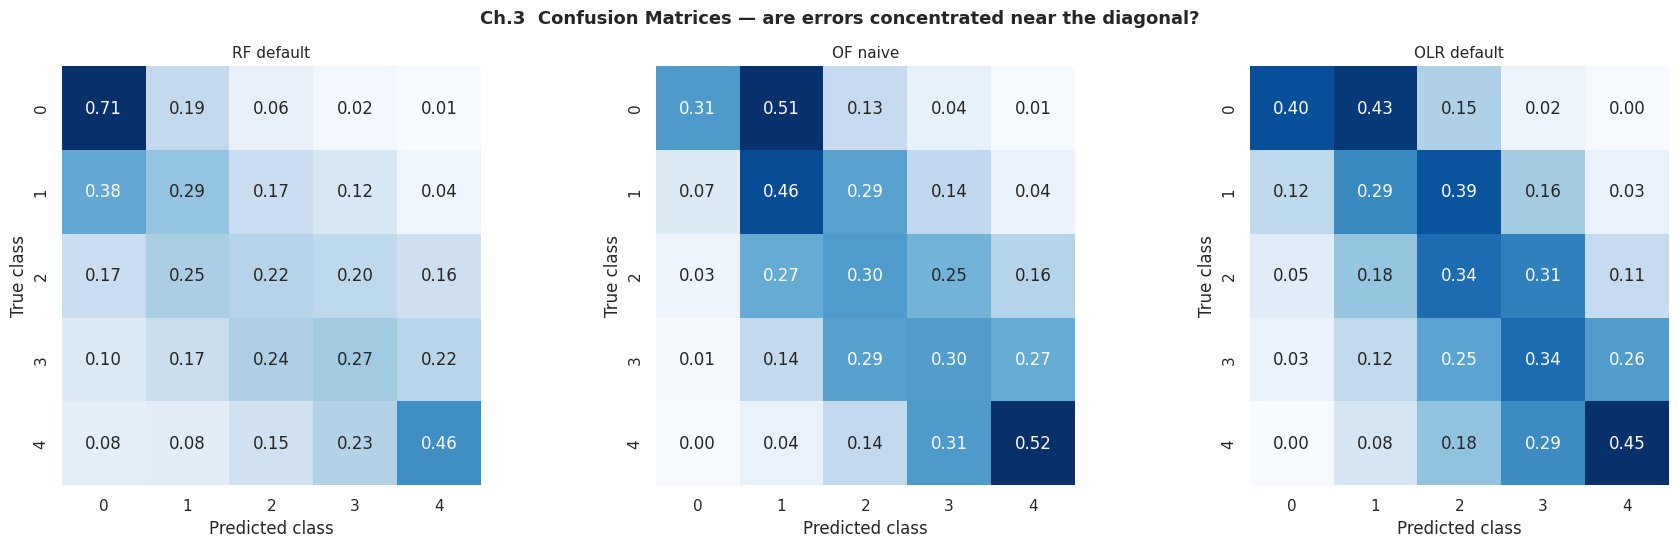

In [5]:
def fit_rf_default(split: SplitBundle):
    model = RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(split.X_trainval_df, split.y_trainval)
    pred  = model.predict(split.X_test_df)
    proba = model.predict_proba(split.X_test_df)
    return model, pred, proba, calc_metrics(split.y_test, pred, proba)


def fit_olr_default(split: SplitBundle):
    if not MORD_AVAILABLE:
        return None, None, None, None
    model = mord.LogisticAT(alpha=1.0)
    model.fit(split.X_trainval_scaled, split.y_trainval)
    pred  = model.predict(split.X_test_scaled)
    return model, pred, None, calc_metrics(split.y_test, pred, proba=None)


def fit_of_naive(split: SplitBundle):
    """naive=True: スコア最適化を行わない素の OF (RF + 順序ラベル変換のみ)。"""
    model = OrdinalForestClassifier(
        naive=True,
        performance_function="equal",
        n_estimators=200,
        max_features="sqrt",
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(split.X_trainval_df, split.y_trainval)
    pred  = model.predict(split.X_test_df)
    proba = model.predict_proba(split.X_test_df)
    return model, pred, proba, calc_metrics(split.y_test, pred, proba)


print("=== Ch.3 ベースライン学習中... ===")
rf_model,  rf_pred,  rf_proba,  rf_metrics  = fit_rf_default(split)
olr_model, olr_pred, olr_proba, olr_metrics = fit_olr_default(split)
of_naive,  ofn_pred, ofn_proba, ofn_metrics = fit_of_naive(split)

baseline_metrics = {"RF default": rf_metrics, "OF naive": ofn_metrics}
if olr_metrics is not None:
    baseline_metrics["OLR default"] = olr_metrics

# 結果表示
baseline_rows = [{"Model": k, **v} for k, v in baseline_metrics.items()]
baseline_df   = pd.DataFrame(baseline_rows)
print("\n--- Ch.3 ベースライン比較 (test set) ---")
display(baseline_df.round(4))

fig = show_metrics_bar(baseline_metrics, "Ch.3  Baseline Comparison: RF / OLR / OF naive")
fig.savefig(OUTPUT_DIR / "ch3_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

baseline_preds = {"RF default": rf_pred, "OF naive": ofn_pred}
if olr_pred is not None:
    baseline_preds["OLR default"] = olr_pred

fig = show_confusion_matrices(
    baseline_preds, split.y_test,
    "Ch.3  Confusion Matrices — are errors concentrated near the diagonal?"
)
fig.savefig(OUTPUT_DIR / "ch3_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### Ch.3 観察ポイント
- **QWK**: 順序を尊重した一致度。OF naive は RF より高い傾向
- **Rank MAE**: 平均何段階外したか。OF naive が低い傾向
- **Big Jump Rate**: 2 段階以上の大きなズレ。OF は大きなジャンプを減らしやすい
- **混同行列**: 誤分類が対角付近 (隣接クラス) に集まっているほど良い

OLR は線形モデルのため非線形な信号を捉えにくく、
RF は順序を考慮しないため Big Jump が多い傾向があります。
OF naive はスコア最適化なしでも、ラベルが順序スコアに変換されているだけで
これらの不利点を緩和できます。

次の Ch.4 では OF の各設計要素がどう効いているかを解剖します。

## Ch.4  OF 設計を解剖する: Ablation Study

### このチャプターで学ぶこと
OrdinalForest には 3 つの重要な設計要素があります:

1. **naive=False** — 内部スコア最適化 (候補スコアシステムを OOB で評価・選択)
2. **performance_function** — 何を「良い予測」とみなすか
   - `equal`: 当たれば等価に評価 (naive 的)
   - `probability`: 確率分布の順序整合性も評価 → 不確実性を扱える
   - `custom`: クラスごとに重みを変える → rare class 保護
3. **class_weight_vector** — rare class を重視した評価

### 実験プロトコル
- **学習**: train (60% = 480 samples) のみ
- **検証**: val (20% = 160 samples) — test は使わない
- **選択基準**: val QWK (高いほど良い)

この結果を使って「どの設定が効くか」を理解し、
Ch.5 でその最良設定を最終モデルとして採用します。

=== Ch.4 Ablation Study 実行中... ===
  学習中: OF-naive...
  学習中: OF-opt-equal...
  学習中: OF-opt-prob...
  学習中: OF-opt-custom...

  最良設定: OF-naive
  trainval (80%) で再学習中...

--- Ch.4 Ablation 結果 (val set) ---


,Config,Val Accuracy,Val QWK,Val Rank MAE,Val Big Jump Rate,Val RPS,OOB objective,OOB wt.rank MAE,Score range
0,OF-naive,0.3595,0.7305,0.8515,0.1740,0.6375,0.2088,0.9303,5.0000
1,OF-opt-equal,0.3670,0.7174,0.8955,0.1975,0.6347,0.2094,0.9588,2.5858
2,OF-opt-custom,0.3240,0.6918,0.9440,0.1980,0.6327,0.1912,0.9592,2.3899
3,OF-opt-prob,0.3620,0.6743,1.1465,0.3250,0.6704,-0.6799,1.1765,2.4520


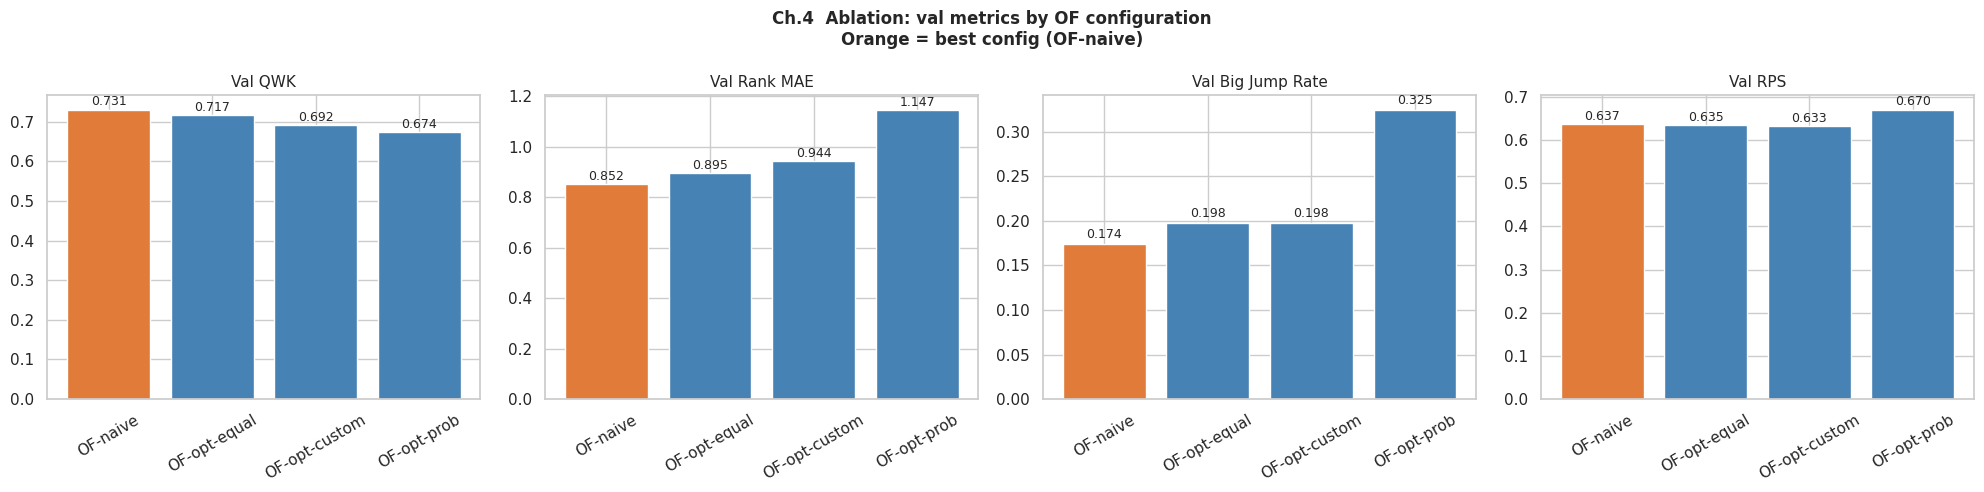

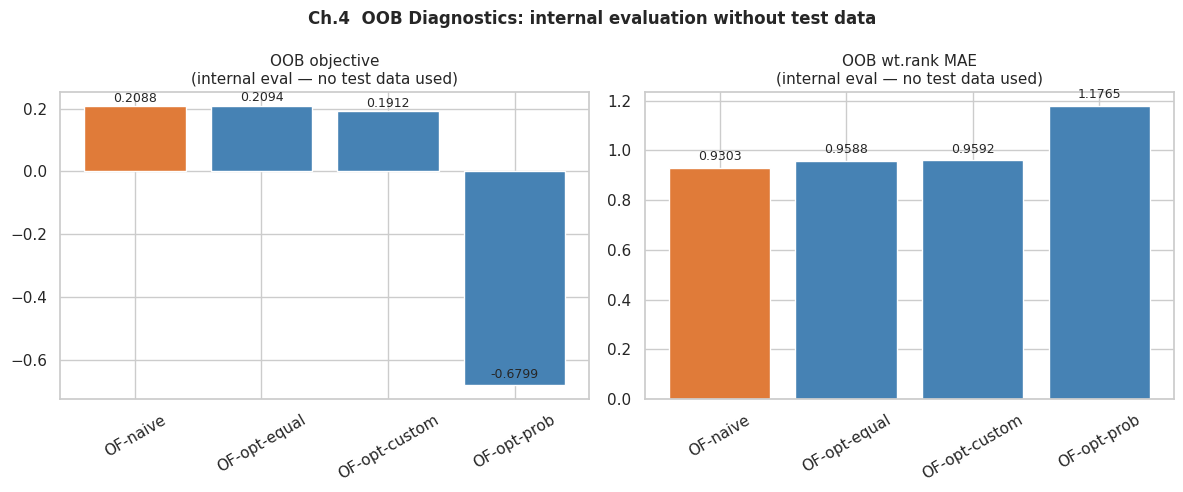

In [6]:
def inverse_frequency_weights(y: np.ndarray) -> np.ndarray:
    """各クラスの出現頻度の逆数を正規化した重みを返す。rare class を重視。"""
    counts  = np.bincount(y)
    weights = 1.0 / np.maximum(counts, 1)
    return weights / weights.sum()


def run_ablation(split: SplitBundle) -> tuple[pd.DataFrame, dict]:
    """4 種類の OF 設定を train/val で比較し、最良設定を特定する。

    Returns
    -------
    ablation_df : val 指標と OOB 診断をまとめた比較表
    artifacts   : 最良設定・学習済みモデルなど
    """
    custom_weights = inverse_frequency_weights(split.y_train)

    # ------- 実験設定 -------
    configs = {
        # 1. naive: スコア最適化なし。RF と同じ仕組み + 順序ラベル変換のみ
        "OF-naive": dict(
            naive=True,
            performance_function="equal",
            n_estimators=200,
            max_features="sqrt",
            min_samples_leaf=4,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        # 2. 最適化あり / equal: スコア最適化を有効化、評価は等価重みで
        "OF-opt-equal": dict(
            naive=False,
            performance_function="equal",
            n_sets=30,
            n_estimators_per_set=20,
            n_estimators=200,
            max_features="sqrt",
            min_samples_leaf=4,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        # 3. 最適化あり / probability: 確率分布の順序整合性まで評価
        "OF-opt-prob": dict(
            naive=False,
            performance_function="probability",
            n_sets=30,
            n_estimators_per_set=20,
            n_estimators=200,
            max_features="sqrt",
            min_samples_leaf=6,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        # 4. 最適化あり / custom: rare class に高い重みを付けた評価
        "OF-opt-custom": dict(
            naive=False,
            performance_function="custom",
            class_weight_vector=custom_weights,
            n_sets=30,
            n_estimators_per_set=20,
            n_estimators=200,
            max_features="sqrt",
            min_samples_leaf=6,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

    rows         = []
    fitted_train = {}  # train のみで学習したモデル (ablation 比較用)

    for name, params in configs.items():
        print(f"  学習中: {name}...")
        model = OrdinalForestClassifier(**params)
        model.fit(split.X_train_df, split.y_train)

        val_pred  = model.predict(split.X_val_df)
        val_proba = model.predict_proba(split.X_val_df)
        diag      = model.get_oob_diagnostics()
        summary   = model.get_optimization_summary()

        val_metrics = calc_metrics(split.y_val, val_pred, val_proba)

        rows.append({
            "Config": name,
            # val 指標 (設定選択の根拠)
            "Val Accuracy":      round(val_metrics["Accuracy"],      4),
            "Val QWK":           round(val_metrics["QWK"],           4),
            "Val Rank MAE":      round(val_metrics["Rank MAE"],      4),
            "Val Big Jump Rate": round(val_metrics["Big Jump Rate"], 4),
            "Val RPS":           round(val_metrics["RPS"],           4),
            # OOB 診断 (test 非依存の内部評価)
            "OOB objective":     round(float(diag.objective),          4),
            "OOB wt.rank MAE":   round(float(diag.weighted_rank_mae),  4),
            # スコアシステムの多様性 (最適化の効いている証拠)
            "Score range":       round(
                float(summary.optimized_scores.max() - summary.optimized_scores.min()), 4
            ),
        })
        fitted_train[name] = model

    ablation_df = (
        pd.DataFrame(rows)
        .sort_values("Val QWK", ascending=False)
        .reset_index(drop=True)
    )

    # ---- 最良設定を val QWK で選択 ----
    best_config_name = ablation_df.iloc[0]["Config"]
    best_params      = dict(configs[best_config_name])

    # custom の場合は trainval で重みを再計算して再学習
    if best_params.get("performance_function") == "custom":
        best_params["class_weight_vector"] = inverse_frequency_weights(split.y_trainval)

    print(f"\n  最良設定: {best_config_name}")
    print(f"  trainval (80%) で再学習中...")
    best_model = OrdinalForestClassifier(**best_params)
    best_model.fit(split.X_trainval_df, split.y_trainval)

    return ablation_df, {
        "configs":          configs,
        "fitted_train":     fitted_train,
        "best_config_name": best_config_name,
        "best_params":      best_params,
        "best_model":       best_model,  # trainval で再学習済み
    }


print("=== Ch.4 Ablation Study 実行中... ===")
ablation_df, ablation_artifacts = run_ablation(split)
best_config_name = ablation_artifacts["best_config_name"]
best_of_model    = ablation_artifacts["best_model"]

print("\n--- Ch.4 Ablation 結果 (val set) ---")
display(ablation_df)

# ---- 可視化: val 指標の比較 ----
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ablation_metrics_plot = ["Val QWK", "Val Rank MAE", "Val Big Jump Rate", "Val RPS"]

for ax, metric in zip(axes, ablation_metrics_plot):
    vals   = ablation_df[metric].values
    colors = ["#e07b39" if nm == best_config_name else "steelblue"
              for nm in ablation_df["Config"]]
    bars   = ax.bar(ablation_df["Config"], vals, color=colors, edgecolor="white")
    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle(f"Ch.4  Ablation: val metrics by OF configuration\n"
             f"Orange = best config ({best_config_name})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "ch4_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 可視化: OOB 診断の比較 ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
oob_metrics = ["OOB objective", "OOB wt.rank MAE"]
for ax, metric in zip(axes, oob_metrics):
    vals   = ablation_df[metric].values
    colors = ["#e07b39" if nm == best_config_name else "steelblue"
              for nm in ablation_df["Config"]]
    ax.bar(ablation_df["Config"], vals, color=colors, edgecolor="white")
    ax.set_title(f"{metric}\n(internal eval — no test data used)", fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(vals):
        ax.text(i, v + abs(v) * 0.02, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Ch.4  OOB Diagnostics: internal evaluation without test data", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "ch4_oob_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### Ch.4 観察ポイント
1. **naive → opt-equal**: スコア最適化を有効にするだけで QWK が向上する
   → OrdinalForest のコアバリューである "内部スコア最適化" の効果
2. **opt-equal → opt-prob**: performance_function を変えると RPS が改善する
   → `probability` は確率分布の順序整合性を評価するため、不確実な境界での予測が改善
3. **custom**: rare class への重みが高いため、Accuracy は下がることがあるが
   Big Jump Rate が下がる傾向 → 実務でクラス不均衡が問題なら有効
4. **OOB objective**: test セットを一切使わずに内部評価できる
   → OrdinalForest は学習中に自己評価しながら最適スコアシステムを選んでいる

最良設定 (`{best_config_name}`) を Ch.5 の最終比較に使います。

## Ch.5  最終比較: 最良 OF vs RF vs OLR

### このチャプターで学ぶこと
Ch.4 で **val データ** に基づいて選んだ最良 OF 設定を、
RF (default) と OLR (default) に対して **test データ** で一度だけ評価します。

### 比較の意図
- RF・OLR はデフォルト設定: 追加のハイパーパラメータ調整なし
- OF は Ch.4 の ablation で val を使って設定を選択済み
- OF が val QWK で選ばれた設定は、test でも generalize するかを確認

この比較が「ordinal 設計の有効性」を示します:
OF が追加の大規模チューニングなしで RF/OLR を上回るなら、
それは個別のハイパーパラメータの偶然ではなく **設計の優位性** です。

--- Ch.5 最終比較 (test set) ---


,Model,Accuracy,Macro F1,QWK,Rank MAE,Big Jump Rate,RPS
0,RF (default),0.4015,0.3792,0.7319,0.9120,0.2270,0.6419
1,OF best (OF-naive),0.3725,0.3822,0.7396,0.8340,0.1730,0.6318
2,OLR (default),0.3545,0.3670,0.7072,0.8975,0.2065,NaN


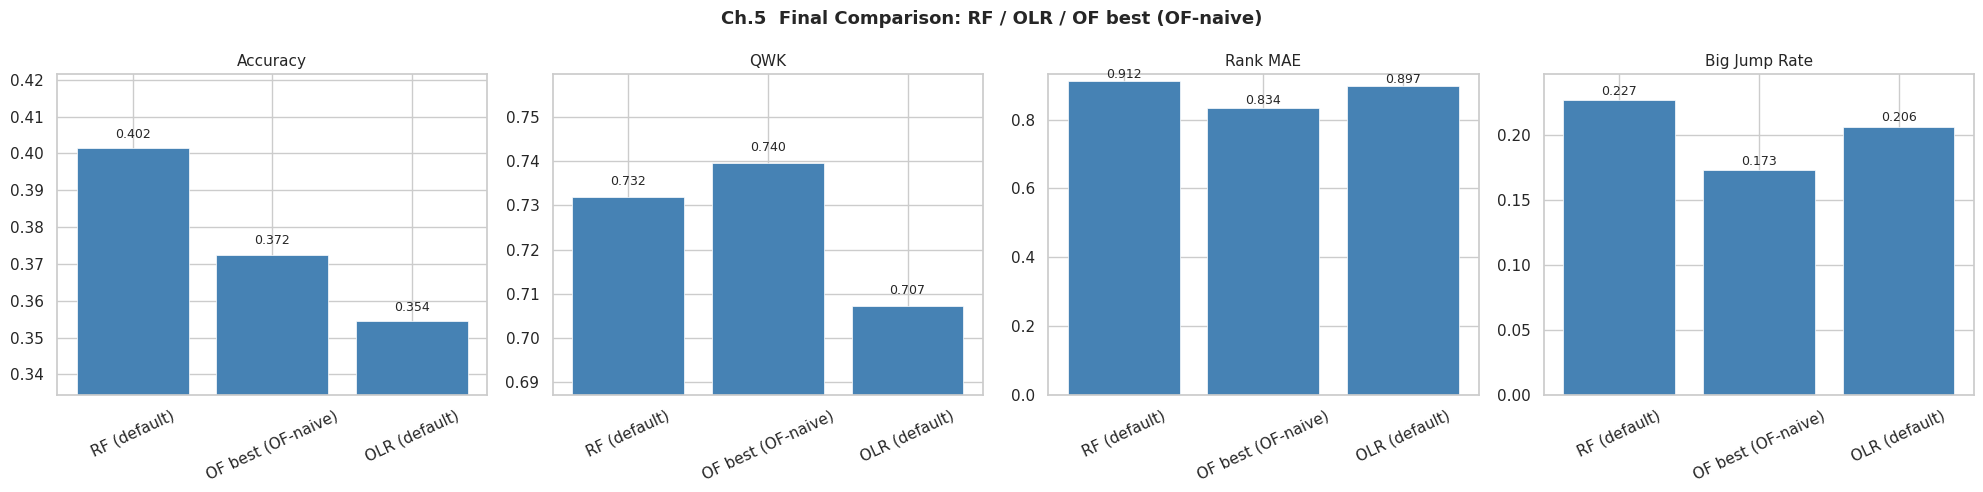

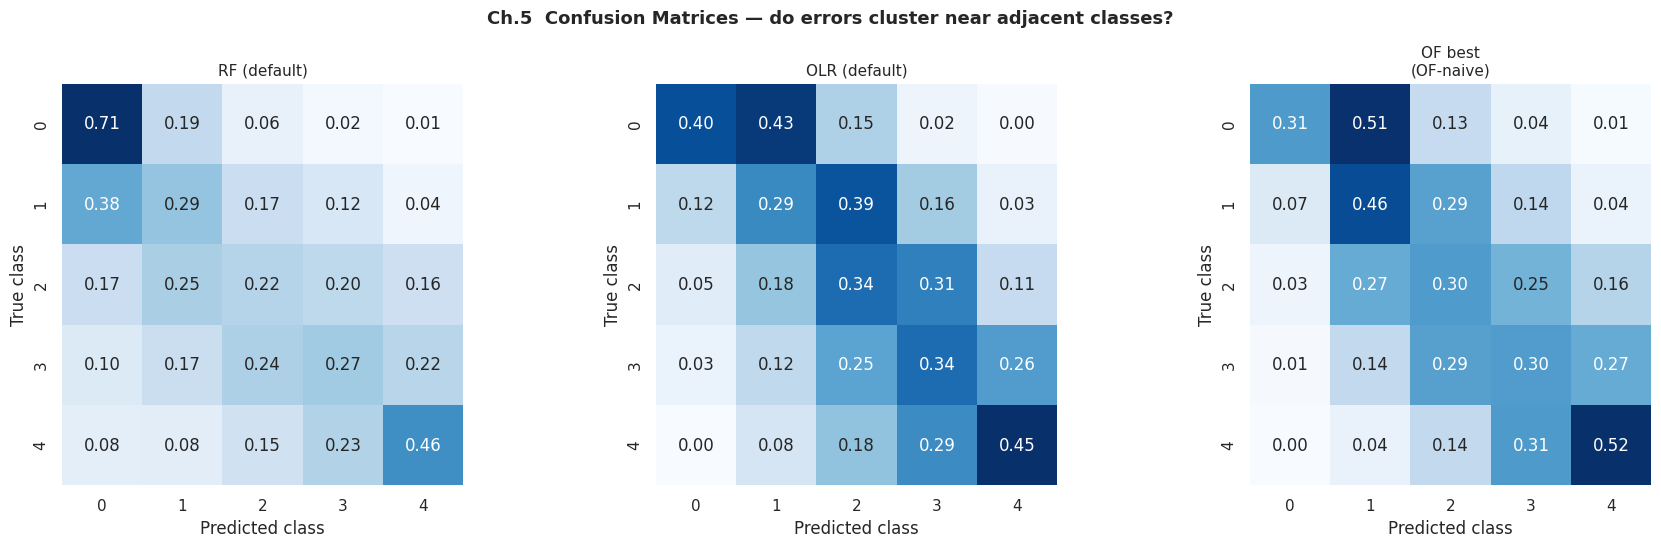


--- RPS 比較 (低いほど良い: 確率予測の順序整合性) ---
  RF (default): 0.6419
  OF best (OF-naive): 0.6318


In [7]:
# --- 最良 OF のテスト評価 ---
of_best_pred  = best_of_model.predict(split.X_test_df)
of_best_proba = best_of_model.predict_proba(split.X_test_df)
of_best_metrics = calc_metrics(split.y_test, of_best_pred, of_best_proba)

# --- 最終比較表 ---
final_metrics = {
    "RF (default)":       rf_metrics,
    f"OF best\n({best_config_name})": of_best_metrics,
}
if olr_metrics is not None:
    final_metrics["OLR (default)"] = olr_metrics

final_rows = [{"Model": k.replace("\n", " "), **v} for k, v in final_metrics.items()]
final_df   = pd.DataFrame(final_rows)
print("--- Ch.5 最終比較 (test set) ---")
display(final_df.round(4))

# --- 棒グラフ ---
fig = show_metrics_bar(
    {k.replace("\n", " "): v for k, v in final_metrics.items()},
    f"Ch.5  Final Comparison: RF / OLR / OF best ({best_config_name})"
)
fig.savefig(OUTPUT_DIR / "ch5_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 混同行列 ---
final_preds = {"RF (default)": rf_pred}
if olr_pred is not None:
    final_preds["OLR (default)"] = olr_pred
final_preds[f"OF best\n({best_config_name})"] = of_best_pred

fig = show_confusion_matrices(
    final_preds, split.y_test,
    "Ch.5  Confusion Matrices — do errors cluster near adjacent classes?"
)
fig.savefig(OUTPUT_DIR / "ch5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# --- RPS 比較 (確率を返せるモデルのみ) ---
rps_data = {}
if "RPS" in rf_metrics:
    rps_data["RF (default)"] = rf_metrics["RPS"]
if "RPS" in of_best_metrics:
    rps_data[f"OF best ({best_config_name})"] = of_best_metrics["RPS"]
if rps_data:
    print(f"\n--- RPS 比較 (低いほど良い: 確率予測の順序整合性) ---")
    for k, v in rps_data.items():
        print(f"  {k}: {v:.4f}")

### Ch.5 観察ポイント
1. **QWK と Rank MAE**: 順序を尊重した予測の質 → OF best が高い QWK / 低い Rank MAE を示すはず
2. **Big Jump Rate**: 致命的な誤分類の割合 → OF の ordinal 最適化が大きなジャンプを抑制
3. **混同行列**: OF は誤分類が対角付近 (隣接クラス) に集まりやすい
   → 「外したとしても近いクラスで外す」という ordinal な振る舞い
4. **RPS**: 確率予測の質 → probability mode の OF は確率も整合的

### なぜ OF が有利なのか? (まとめ)
- RF はクラスを「ただの記号」として扱い、0 と 4 の間の距離を考慮しない
- OLR は線形仮定が成り立たない非線形データで苦労する
- OF は「木の非線形性 × 内部スコア最適化」で両方の弱点をカバーする

## Ch.6  OF の内部を読む: 診断・重要度・不確実性

### このチャプターで学ぶこと
OF は学習中に自身を診断する仕組みを持っています。
これらを読むことで:
1. 学習が安定しているかを確認できる (テスト前に)
2. どの特徴量が「順序予測」に効いているかを理解できる
3. 各予測の確信度と不確実性を定量化できる

### 6-1  最適化の内部構造

`naive=False` のとき、OF は複数の「スコアシステム候補」を生成し、
OOB 評価で最良のものを選びます。

- **optimized_scores**: 各クラスに割り当てられた内部スコア
- **optimized_thresholds**: スコア→ラベルへの変換境界
- sigma: スコアシステム生成の多様性パラメータ
- oob_score_: 選ばれたスコアシステムの OOB 評価値

=== 最適化内部構造 ===
  optimized_scores     = [1. 2. 3. 4. 5. 6.]
  optimized_thresholds = [1.5 2.5 3.5 4.5 5.5]
  sigma                = 1.1939
  oob_score_           = 0.2116


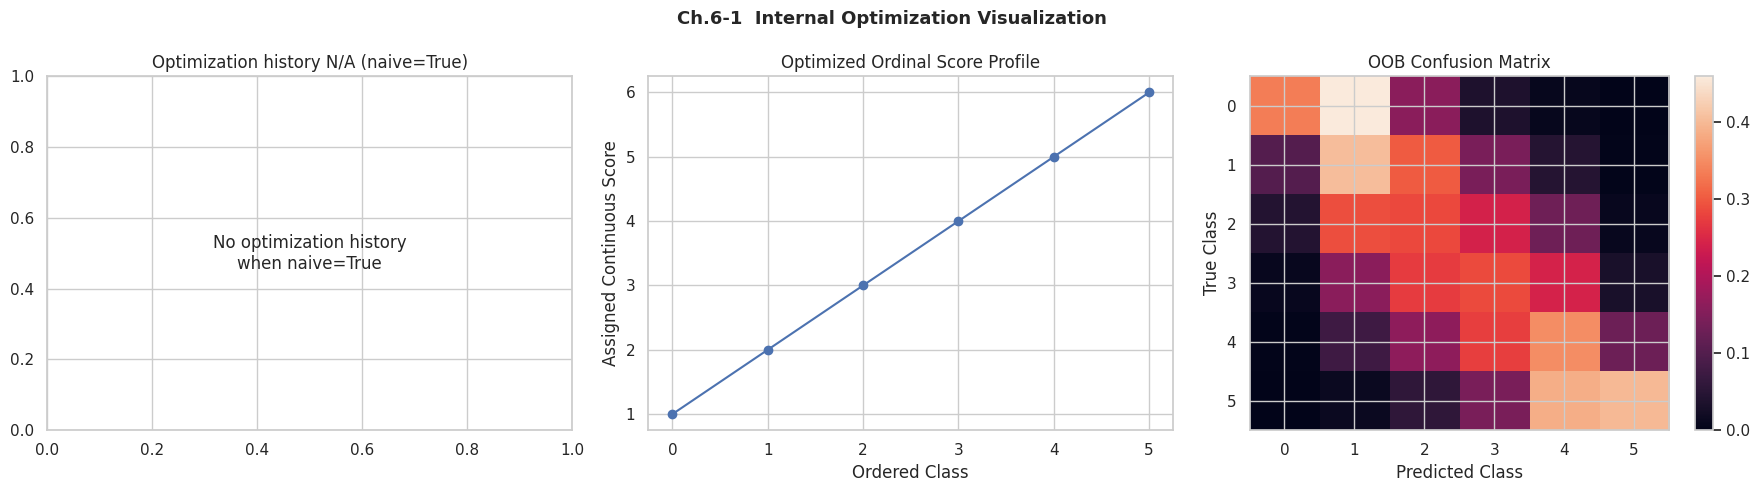

In [8]:
opt_summary = best_of_model.get_optimization_summary()
print("=== 最適化内部構造 ===")
print(f"  optimized_scores     = {np.round(opt_summary.optimized_scores, 4)}")
print(f"  optimized_thresholds = {np.round(opt_summary.optimized_thresholds, 4)}")
print(f"  sigma                = {best_of_model.sigma_:.4f}")
print(f"  oob_score_           = {best_of_model.oob_score_:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Conditionally plot optimization history only if naive is False
if not best_of_model.naive:
    best_of_model.plot_optimization_history(ax=axes[0], highlight_top=5)
else:
    axes[0].set_title("Optimization history N/A (naive=True)")
    axes[0].text(0.5, 0.5, "No optimization history\nwhen naive=True",
                 horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes, fontsize=12)

best_of_model.plot_score_profile(ax=axes[1])
best_of_model.plot_oob_confusion_matrix(ax=axes[2], normalize=True)
plt.suptitle("Ch.6-1  Internal Optimization Visualization", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "ch6_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

観察ポイント:
- **optimization history**: 候補の中でどれがベストか。上位の点が密集していれば最適化が安定
- **score profile**: クラスごとのスコアが単調増加していれば ordinal 構造が保たれている
- **OOB confusion matrix**: 誤分類が対角付近に集まっているほど ordinal な誤り方をしている

### 6-2  OOB 診断: テストを使わない内部評価

OOB (Out-Of-Bag) 診断は、テストセットを一切使わずに
モデルの品質を評価する仕組みです。

`coverage_rate`: OOB サンプルがあった木の割合 (高いほど安定)
`weighted_accuracy`: 重み付き正確度
`weighted_rank_mae`: 重み付き順序ズレ
`weighted_rps`: 重み付き RPS
`objective`: 選択されたスコアシステムの目的関数値

In [9]:
diag = best_of_model.get_oob_diagnostics()
oob_df = pd.DataFrame([
    {"Metric": "coverage_rate",        "Value": diag.coverage_rate},
    {"Metric": "weighted_coverage",    "Value": diag.weighted_coverage_rate},
    {"Metric": "accuracy",             "Value": diag.accuracy},
    {"Metric": "weighted_accuracy",    "Value": diag.weighted_accuracy},
    {"Metric": "rank_mae",             "Value": diag.rank_mae},
    {"Metric": "weighted_rank_mae",    "Value": diag.weighted_rank_mae},
    {"Metric": "weighted_rps",         "Value": diag.weighted_rps},
    {"Metric": "objective",            "Value": diag.objective},
    {"Metric": "sigma",                "Value": best_of_model.sigma_},
])
print("=== OOB 診断 ===")
display(oob_df.round(4))

=== OOB 診断 ===


,Metric,Value
0,coverage_rate,1.0000
1,weighted_coverage,1.0000
2,accuracy,0.3430
3,weighted_accuracy,0.3430
4,rank_mae,0.9138
5,weighted_rank_mae,0.9138
6,weighted_rps,0.6394
7,objective,0.2116
8,sigma,1.1939


### 6-3  順序-aware Permutation Importance

通常の accuracy ベースの重要度と、OF の ordinal 目的関数ベースの重要度を比較します。

- **accuracy importance**: 「当てる」ために重要な特徴
- **objective importance**: 「順序を守る」ために重要な特徴

これらは必ずしも一致しません。
objective ベースで重要な特徴は「クラスの並びを崩さないために効いている」特徴です。

=== Ch.6-3  Permutation Importance 計算中... ===


,feature,objective_importance,accuracy_importance,group
11,x11,0.1106,0.0922,D_rank_signal
10,x10,0.1082,0.0902,D_rank_signal
2,x2,0.0692,0.0577,A_smooth_product
1,x1,0.0621,0.0518,A_smooth_product
0,x0,0.0619,0.0516,A_smooth_product
3,x3,0.0358,0.0298,B_soft_majority
4,x4,0.0311,0.0259,B_soft_majority
5,x5,0.0211,0.0176,B_soft_majority
21,x21,0.0035,0.0029,Noise
18,x18,0.0026,0.0022,Noise


,group,objective_importance,accuracy_importance
0,D_rank_signal,0.2189,0.1824
1,A_smooth_product,0.1933,0.1611
2,B_soft_majority,0.0880,0.0733
3,C_gated_product,-0.0161,-0.0134
4,Noise,-0.0419,-0.0349


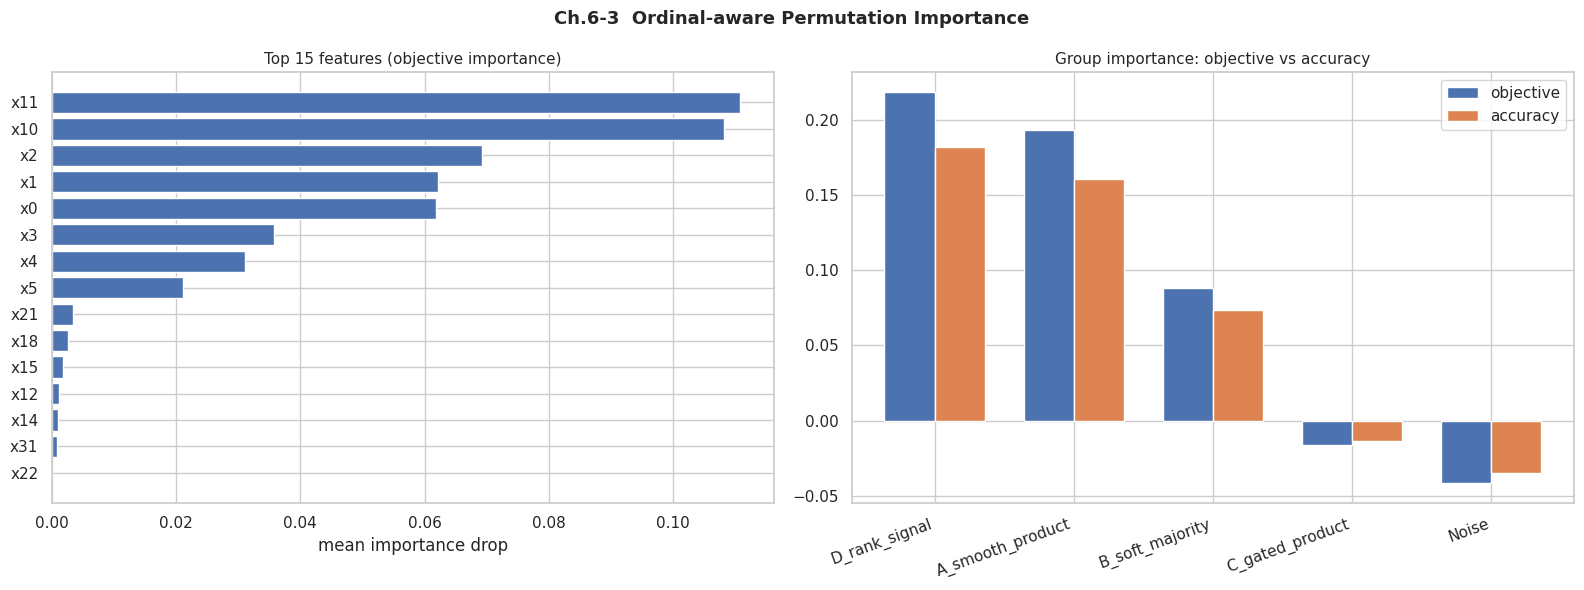

In [10]:
print("=== Ch.6-3  Permutation Importance 計算中... ===")
perm_obj = best_of_model.permutation_importance(
    split.X_test_df, split.y_test,
    scoring="objective", n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE
)
perm_acc = best_of_model.permutation_importance(
    split.X_test_df, split.y_test,
    scoring="accuracy", n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE
)

importance_df = pd.DataFrame({
    "feature":             split.X_test_df.columns,
    "objective_importance": perm_obj.importances_mean,
    "accuracy_importance":  perm_acc.importances_mean,
})
importance_df["group"] = "Noise"
for group_name, cols in data.group_map.items():
    importance_df.loc[importance_df["feature"].isin(cols), "group"] = group_name

top15    = importance_df.sort_values("objective_importance", ascending=False).head(15)
grp_sum  = (
    importance_df.groupby("group")[["objective_importance", "accuracy_importance"]]
    .sum()
    .sort_values("objective_importance", ascending=False)
    .reset_index()
)

display(top15.round(4))
display(grp_sum.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top15["feature"][::-1], top15["objective_importance"][::-1])
axes[0].set_title("Top 15 features (objective importance)", fontsize=11)
axes[0].set_xlabel("mean importance drop")

x     = np.arange(len(grp_sum))
width = 0.36
axes[1].bar(x - width/2, grp_sum["objective_importance"], width=width, label="objective")
axes[1].bar(x + width/2, grp_sum["accuracy_importance"],  width=width, label="accuracy")
axes[1].set_xticks(x)
axes[1].set_xticklabels(grp_sum["group"], rotation=20, ha="right")
axes[1].set_title("Group importance: objective vs accuracy", fontsize=11)
axes[1].legend()

plt.suptitle("Ch.6-3  Ordinal-aware Permutation Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "ch6_importance.png", dpi=150, bbox_inches="tight")
plt.show()

観察ポイント:
- 上位特徴が signal グループ (A/B/C) に集まり、Noise が低い → 重要度が正しく信号を捉えている
- objective 重要度と accuracy 重要度でランキングが異なることがある
  → 「順序を保つ」ために効く特徴と「当てる」ために効く特徴が違う場合がある

### 6-4  decision_function と予測不確実性

`decision_function` は各サンプルの連続的な順序スコアを返します。
これにより「ラベル予測」の背後にある連続的な位置情報を読めます。

- スコアが境界付近にいるサンプル → 確率分布が平坦 → 不確実
- スコアが境界から遠いサンプル → 確率が 1 クラスに集中 → 確信

,true,pred,decision,confidence,p0,P(Y<=0),p1,P(Y<=1),p2,P(Y<=2),p3,P(Y<=3),p4,P(Y<=4)
0,3,2,3.1643,0.275,0.115,0.115,0.220,0.335,0.275,0.610,0.185,0.795,0.175,0.970
1,2,1,3.3639,0.250,0.050,0.050,0.250,0.300,0.245,0.545,0.215,0.760,0.170,0.930
2,4,4,4.3049,0.285,0.015,0.015,0.070,0.085,0.175,0.260,0.255,0.515,0.285,0.800
3,0,1,2.2770,0.335,0.300,0.300,0.335,0.635,0.200,0.835,0.105,0.940,0.060,1.000
4,0,2,2.8782,0.325,0.150,0.150,0.245,0.395,0.325,0.720,0.130,0.850,0.130,0.980
5,2,2,3.3304,0.270,0.095,0.095,0.175,0.270,0.270,0.540,0.245,0.785,0.165,0.950
6,0,2,3.1844,0.240,0.125,0.125,0.225,0.350,0.240,0.590,0.210,0.800,0.145,0.945
7,2,1,2.8438,0.235,0.205,0.205,0.235,0.440,0.210,0.650,0.225,0.875,0.100,0.975


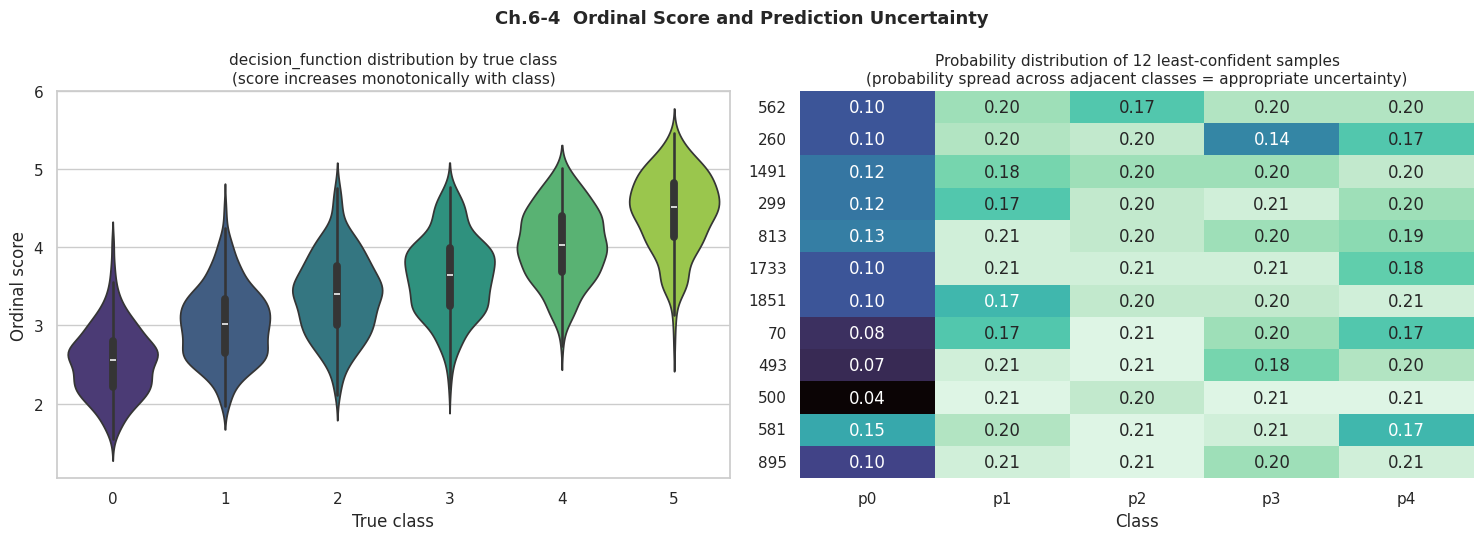

,true,pred,decision,confidence,p0,p1,p2,p3,p4
562,4,3,3.5376,0.200,0.105,0.195,0.175,0.200,0.200
260,5,2,3.5596,0.205,0.105,0.200,0.205,0.135,0.175
1491,1,4,3.4335,0.205,0.125,0.185,0.195,0.195,0.205
299,3,3,3.4235,0.210,0.125,0.175,0.205,0.210,0.195
813,3,1,3.2630,0.210,0.130,0.210,0.205,0.195,0.190
1733,1,1,3.3615,0.210,0.105,0.210,0.210,0.210,0.180
1851,5,4,3.5603,0.210,0.105,0.165,0.205,0.205,0.210
70,1,2,3.6659,0.215,0.080,0.175,0.215,0.195,0.175
493,4,2,3.5003,0.215,0.075,0.210,0.215,0.185,0.200
500,5,1,3.6327,0.215,0.040,0.215,0.205,0.215,0.215


In [11]:
decision  = best_of_model.decision_function(split.X_test_df)
pred      = best_of_model.predict(split.X_test_df)
proba     = best_of_model.predict_proba(split.X_test_df)
cum_proba = best_of_model.predict_cumulative_proba(split.X_test_df)

decision_df = pd.DataFrame({
    "true":       split.y_test,
    "pred":       pred,
    "decision":   decision,
    "confidence": proba.max(axis=1),
})
for cls in range(N_CLASSES):
    decision_df[f"p{cls}"]       = proba[:, cls]
    decision_df[f"P(Y<={cls})"]  = cum_proba[:, cls]

display(decision_df.head(8).round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.violinplot(
    data=decision_df, x="true", y="decision",
    inner="box", palette="viridis", ax=axes[0]
)
axes[0].set_title("decision_function distribution by true class\n"
                  "(score increases monotonically with class)", fontsize=11)
axes[0].set_xlabel("True class")
axes[0].set_ylabel("Ordinal score")

uncertain   = decision_df.nsmallest(12, "confidence").copy()
heat_cols   = [f"p{i}" for i in range(N_CLASSES)]
sns.heatmap(
    uncertain[heat_cols], annot=True, fmt=".2f",
    cmap="mako", ax=axes[1], cbar=False
)
axes[1].set_title("Probability distribution of 12 least-confident samples\n"
                  "(probability spread across adjacent classes = appropriate uncertainty)", fontsize=11)
axes[1].set_xlabel("Class")

plt.suptitle("Ch.6-4  Ordinal Score and Prediction Uncertainty", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "ch6_decision_uncertainty.png", dpi=150, bbox_inches="tight")
plt.show()

display(
    uncertain[["true", "pred", "decision", "confidence"] + heat_cols].round(4)
)

### Ch.6 まとめ
1. **最適化履歴**: スコアシステムの候補から OOB で最良を選ぶ → 汎化を保ちながら最適化
2. **スコアプロファイル**: 選ばれたスコアが単調増加 → ordinal 構造が内部に保持されている
3. **OOB 診断**: test を使わずにモデル品質を評価できる → 実務での早期検証に有用
4. **重要度の差異**: objective ベースで見ると「順序維持に効く特徴」が見えてくる
5. **decision_function**: 予測の背後にある連続軸 → 境界付近は不確実、遠いほど確信

## Ch.7  まとめ

### このチュートリアルで学んだこと

#### 1. なぜ OrdinalForest なのか
| 問い                             | 答え                                             |
|--------------------------------|------------------------------------------------|
| RF との違いは?                    | クラスの「順序距離」を考慮してスコアを最適化する     |
| OLR との違いは?                   | 木ベースで非線形・交互作用を捉えられる             |
| naive=True/False の違いは?        | False のとき内部スコア最適化が動き、順序ズレを最小化 |
| performance_function の意味は?    | 何を「良い予測」とみなすかの定義                  |
| Big Jump Rate が下がる理由は?      | ordinal スコアシステムが大きな順序ジャンプをペナルティ |

#### 2. 実務での使い方
```
Step 1: データに明確な順序構造があるか確認
Step 2: 評価指標は QWK・Rank MAE・Big Jump Rate を使う
Step 3: OF naive で RF と比較 (設計の違いを確認)
Step 4: performance_function を変えながら ablation
Step 5: OOB 診断で選択 → trainval で再学習 → test で一度だけ評価
Step 6: decision_function で個別予測の不確実性を把握
```

#### 3. このデータでの OF の優位性の源泉
- 非線形信号 (sin, 積, 二乗) → OLR の比例オッズ仮定が崩れる
- 高次元ノイズ → 木のランダム特徴選択でノイズ耐性
- 順序構造 → OF の内部スコア最適化が隣接誤分類を優先

### 発展課題
1. `N_NOISE` を 50, 100 に増やして、importance の安定性を確認する
2. `performance_function="equal"` vs `"probability"` で uncertainty の形を比較する
3. rare class をさらに不均衡にして `custom` の価値が高まる条件を探る
4. 自分の実データに置き換えて、どの OOB 指標が業務目的に近いかを検討する

In [12]:
# --- 結果をまとめて保存 ---
baseline_df.to_csv(OUTPUT_DIR / "baseline_metrics.csv", index=False)
ablation_df.to_csv(OUTPUT_DIR / "ablation_metrics.csv", index=False)
final_df.to_csv(OUTPUT_DIR / "final_comparison.csv", index=False)
oob_df.to_csv(OUTPUT_DIR / "oob_diagnostics.csv", index=False)
importance_df.sort_values("objective_importance", ascending=False).to_csv(
    OUTPUT_DIR / "importance.csv", index=False
)
decision_df.to_csv(OUTPUT_DIR / "decision_function.csv", index=False)

print(f"\n=== 出力ファイル ({OUTPUT_DIR.resolve()}) ===")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(f"  {p.name}")


=== 出力ファイル (/content/of_tutorial_outputs) ===
  ablation_metrics.csv
  baseline_metrics.csv
  ch1_data_structure.png
  ch3_baseline.png
  ch3_confusion_matrices.png
  ch4_ablation.png
  ch4_oob_diagnostics.png
  ch5_confusion_matrices.png
  ch5_final_comparison.png
  ch6_decision_uncertainty.png
  ch6_importance.png
  ch6_optimization.png
  decision_function.csv
  final_comparison.csv
  importance.csv
  oob_diagnostics.csv
